# Proyek Klasifikasi Gambar: [CIFAR-10 Dataset]
- **Nama:** [Dewa Bagus Putu Arya Dhananjaya]
- **Email:** [dewadhanan@gmail.com]
- **ID Dicoding:** [dewadhanan25]

## Import Semua Packages/Library yang Digunakan

In [25]:
!pip install tensorflow
!pip install tensorflowjs

In [32]:
## Import Semua Packages/Library yang Digunakan
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflowjs as tfjs
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## Data Preparation

### Data Loading

In [4]:
# ====== LOAD DATASET (CIFAR-10; >1000 images) ======

# CIFAR-10: 60000 images (50000 train + 10000 test), 10 classes
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()
y_train_full = y_train_full.flatten()
y_test = y_test.flatten()

# Combine and then split to get train/val/test as requested
# We'll take x_train_full (50000) and split into train + val
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.1, random_state=SEED, stratify=y_train_full
)
print("Train:", x_train.shape, "Val:", x_val.shape, "Test:", x_test.shape)

# Normalize images to [0,1]
x_train = x_train.astype("float32") / 255.0
x_val = x_val.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Parameters
IMG_HEIGHT, IMG_WIDTH, IMG_CH = x_train.shape[1:]
BATCH_SIZE = 64
NUM_CLASSES = 10
EPOCHS = 25

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train: (45000, 32, 32, 3) Val: (5000, 32, 32, 3) Test: (10000, 32, 32, 3)


Kelas-kelas dalam dataset:
0: airplane
1: automobile
2: bird
3: cat
4: deer
5: dog
6: frog
7: horse
8: ship
9: truck


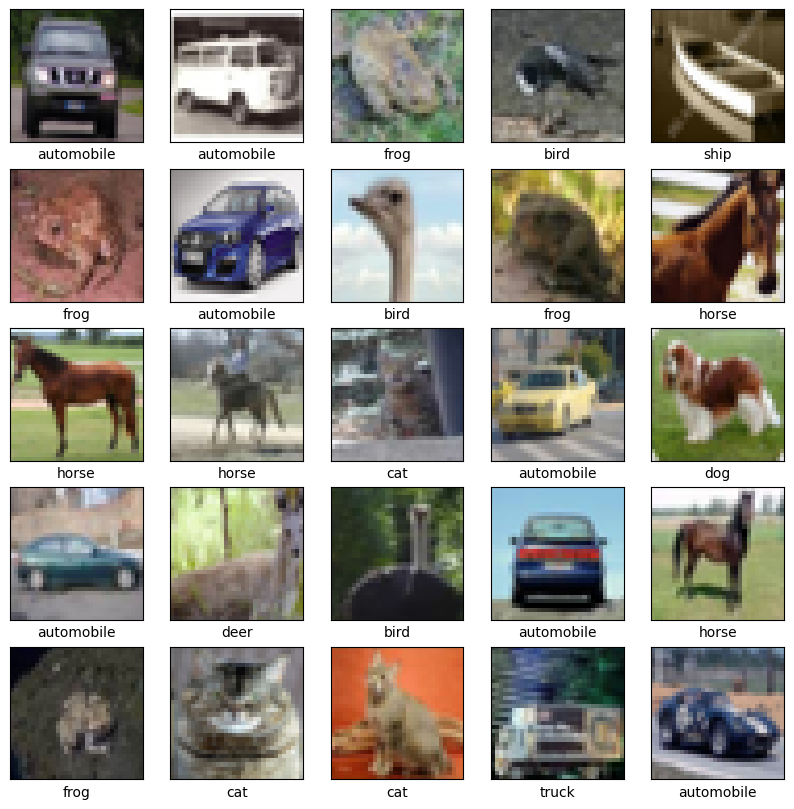

In [5]:
# Definisikan nama-nama kelas untuk dataset CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Untuk menampilkan nama kelas
print("Kelas-kelas dalam dataset:")
for i, class_name in enumerate(class_names):
    print(f"{i}: {class_name}")

plt.figure(figsize=(10, 10))
for i in range(25): # Menampilkan 25 gambar pertama
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i]) # Menggunakan x_train dari konteks
    # y_train adalah array 1D, jadi langsung gunakan indeks
    plt.xlabel(class_names[y_train[i]])
plt.show()

### Data Preprocessing

#### Split Dataset

In [6]:
# ====== DATA AUGMENTATION (ImageDataGenerator) ======

# This helps generalization and helps reach higher test accuracy
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='reflect'
)
train_generator = train_datagen.flow(x_train, y_train, batch_size=BATCH_SIZE, shuffle=True, seed=SEED)

# Validation / test generators (no augmentation)
val_datagen = ImageDataGenerator()
val_generator = val_datagen.flow(x_val, y_val, batch_size=BATCH_SIZE, shuffle=False)

test_datagen = ImageDataGenerator()
test_generator = test_datagen.flow(x_test, y_test, batch_size=BATCH_SIZE, shuffle=False)

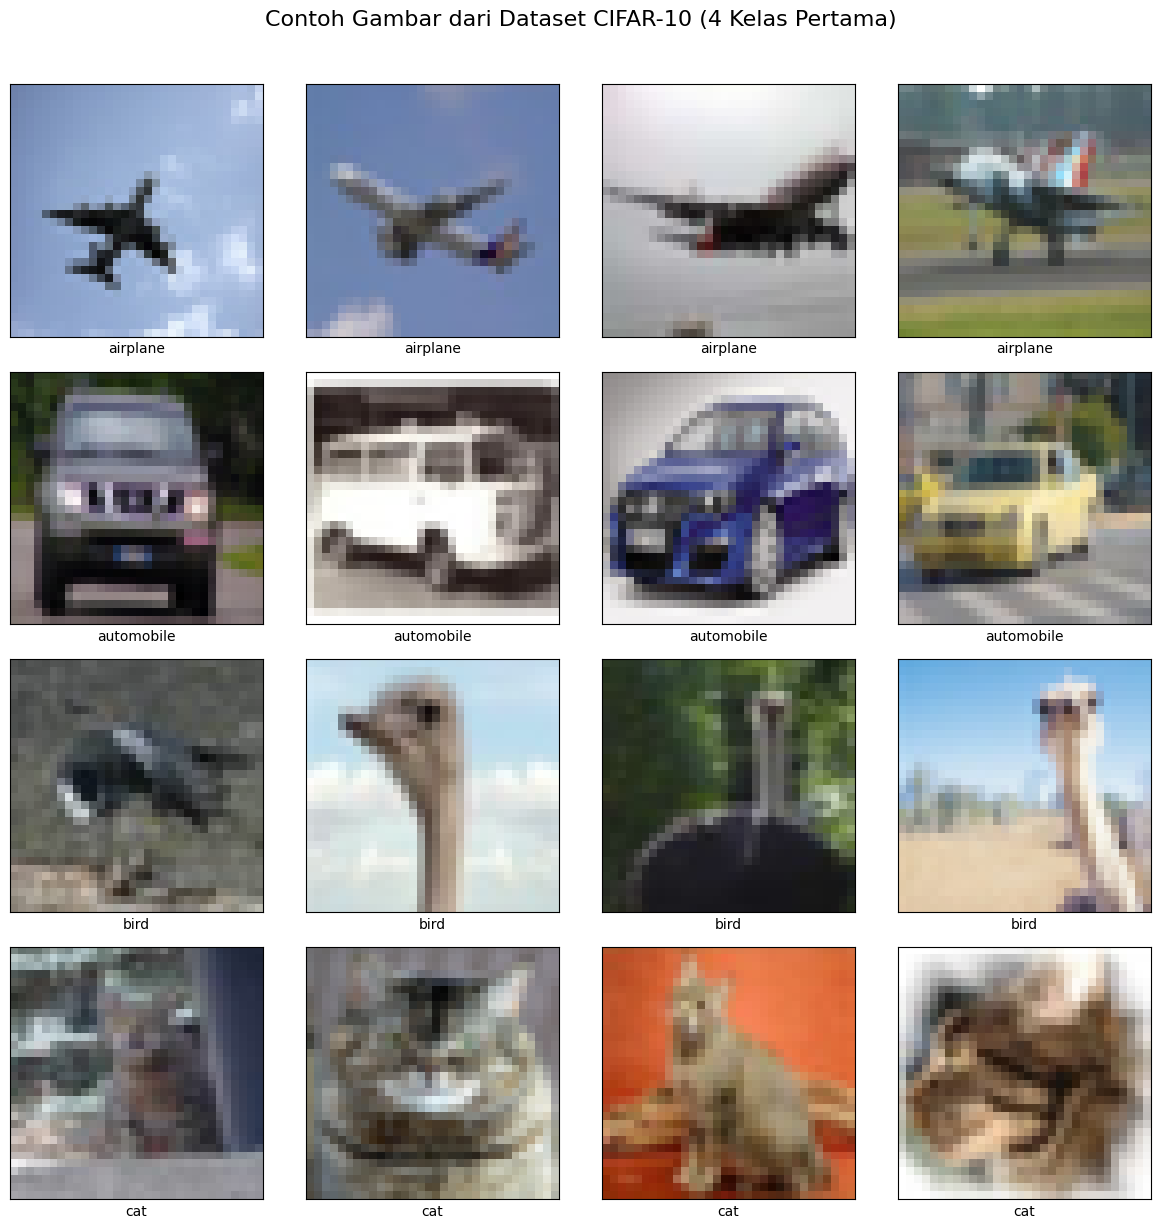

In [7]:
# Untuk menampilkan beberapa contoh gambar dari dataset dan membaginya menjadi 4 kelas
plt.figure(figsize=(12, 12))
for i in range(4):  # Menampilkan 4 kelas
    # Ambil indeks gambar dari kelas saat ini
    class_indices = np.where(y_train == i)[0]
    # Ambil 4 gambar pertama dari kelas tersebut
    for j in range(4):
        idx = class_indices[j]
        plt.subplot(4, 4, i * 4 + j + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(x_train[idx])
        plt.xlabel(class_names[y_train[idx]])
plt.suptitle("Contoh Gambar dari Dataset CIFAR-10 (4 Kelas Pertama)", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

In [8]:
# ====== Filter Dataset for 4 Classes ======

# Choose 4 classes to keep (e.g., airplane, automobile, bird, cat)
selected_classes = [0, 1, 2, 3] # Indices for 'airplane', 'automobile', 'bird', 'cat'

# Filter training data
train_indices = np.isin(y_train, selected_classes)
x_train_4_classes = x_train[train_indices]
y_train_4_classes = y_train[train_indices]

# Filter validation data
val_indices = np.isin(y_val, selected_classes)
x_val_4_classes = x_val[val_indices]
y_val_4_classes = y_val[val_indices]

# Filter test data
test_indices = np.isin(y_test, selected_classes)
x_test_4_classes = x_test[test_indices]
y_test_4_classes = y_test[test_indices]

# Update NUM_CLASSES
NUM_CLASSES = len(selected_classes)

print(f"Dataset filtered to {NUM_CLASSES} classes.")
print("Filtered Train:", x_train_4_classes.shape, "Filtered Val:", x_val_4_classes.shape, "Filtered Test:", x_test_4_classes.shape)

# Update the generators to use the filtered data
train_generator = train_datagen.flow(x_train_4_classes, y_train_4_classes, batch_size=BATCH_SIZE, shuffle=True, seed=SEED)
val_generator = val_datagen.flow(x_val_4_classes, y_val_4_classes, batch_size=BATCH_SIZE, shuffle=False)
test_generator = test_datagen.flow(x_test_4_classes, y_test_4_classes, batch_size=BATCH_SIZE, shuffle=False)

# Update class_names to reflect the selected classes
class_names_4_classes = [class_names[i] for i in selected_classes]
print("\nSelected classes:", class_names_4_classes)

Dataset filtered to 4 classes.
Filtered Train: (18000, 32, 32, 3) Filtered Val: (2000, 32, 32, 3) Filtered Test: (4000, 32, 32, 3)

Selected classes: ['airplane', 'automobile', 'bird', 'cat']


## Modelling

In [9]:
# ====== BUILD MODEL (Kriteria: Sequential + Conv2D + Pooling) ======
def build_cnn_model(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CH), num_classes=NUM_CLASSES):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.35),

        layers.Conv2D(256, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.4),

        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_cnn_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 3,250,756 (12.40 MB)

 Trainable params: 3,247,940 (12.39 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [10]:
# ====== COMPILE MODEL ======
initial_learning_rate = 1e-3
optimizer = keras.optimizers.Adam(learning_rate=initial_learning_rate)
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
# ====== CALLBACKS: LR SCHEDULE, EarlyStopping, Checkpoint ======
callbacks = []

# ReduceLROnPlateau
lr_reducer = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',   # Pantau val_loss
    factor=0.5,           # Turunkan LR menjadi setengah jika stagnan
    patience=3,           # Jika val_loss tidak membaik selama 3 epoch
    min_lr=1e-6,          # LR minimum
    verbose=1
)
callbacks.append(lr_reducer)

# EarlyStopping
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',   # Pantau val_loss
    patience=7,           # Hentikan training jika val_loss tidak membaik 7 epoch
    restore_best_weights=True,
    verbose=1
)
callbacks.append(early_stop)

# ModelCheckpoint
os.makedirs("checkpoints", exist_ok=True)
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    "checkpoints/best_model.keras",
    monitor="val_accuracy",  # Simpan model terbaik berdasarkan val_accuracy
    save_best_only=True,
    verbose=1
)
callbacks.append(checkpoint_cb)

In [12]:
# ====== TRAIN ======
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5834 - loss: 1.2642
Epoch 1: val_accuracy improved from -inf to 0.35550, saving model to checkpoints/best_model.keras
282/282 ━━━━━━━━━━━━━━━━━━━━ 517s 2s/step - accuracy: 0.5836 - loss: 1.2634 - val_accuracy: 0.3555 - val_loss: 2.2414 - learning_rate: 0.0010
Epoch 2/25
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7156 - loss: 0.7349
Epoch 2: val_accuracy improved from 0.35550 to 0.67200, saving model to checkpoints/best_model.keras
282/282 ━━━━━━━━━━━━━━━━━━━━ 508s 2s/step - accuracy: 0.7157 - loss: 0.7348 - val_accuracy: 0.6720 - val_loss: 0.8662 - learning_rate: 0.0010
Epoch 3/25
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7582 - loss: 0.6063
Epoch 3: val_accuracy improved from 0.67200 to 0.76800, saving model to checkpoints/best_model.keras
282/282 ━━━━━━━━━━━━━━━━━━━━ 518s 2s/step - accuracy: 0.7583 - loss: 0.6062 - val_accuracy: 0.7680 - val_loss: 0.5843 - learning_rate: 0.0010
Epoch 4/25
282/282 

## Evaluasi dan Visualisasi

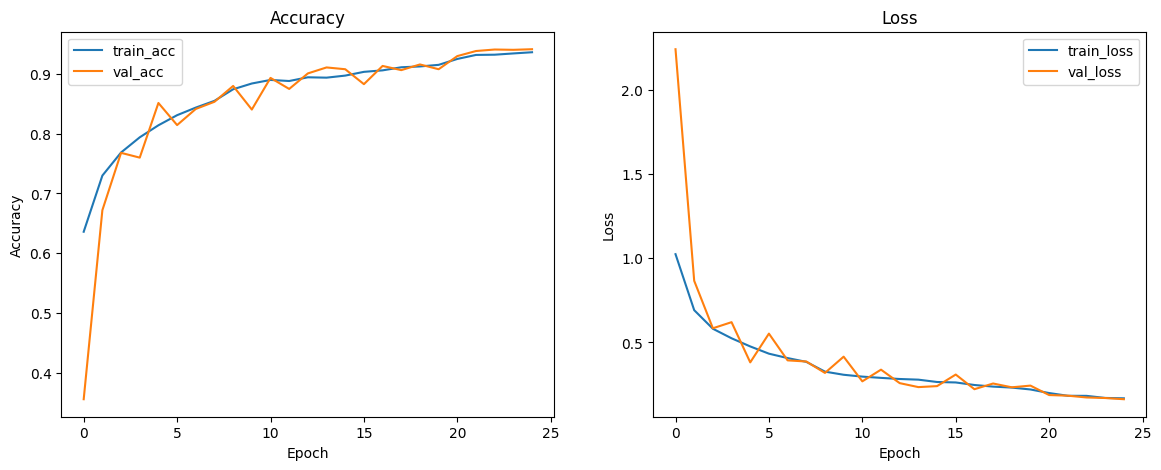

In [13]:
# ====== PLOT ACCURACY & LOSS ======
def plot_history(history):
    fig, axs = plt.subplots(1,2,figsize=(14,5))
    # Accuracy
    axs[0].plot(history.history['accuracy'], label='train_acc')
    axs[0].plot(history.history['val_accuracy'], label='val_acc')
    axs[0].set_title('Accuracy')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Accuracy')
    axs[0].legend()
    # Loss
    axs[1].plot(history.history['loss'], label='train_loss')
    axs[1].plot(history.history['val_loss'], label='val_loss')
    axs[1].set_title('Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Loss')
    axs[1].legend()
    plt.show()
plot_history(history)

In [14]:
# Muat model terbaik
best_model = keras.models.load_model("checkpoints/best_model.keras")
# Evaluasi model pada data test
print("\n--- Evaluating Model on Test Data ---")
test_loss, test_accuracy = best_model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


--- Evaluating Model on Test Data ---
63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 503ms/step - accuracy: 0.9321 - loss: 0.1857
Test Loss: 0.1815
Test Accuracy: 0.9320


In [18]:
# Prediksi pada data test yang sudah difilter 4 kelas
y_pred_probs = best_model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test_4_classes, y_pred, target_names=class_names_4_classes))

63/63 ━━━━━━━━━━━━━━━━━━━━ 27s 422ms/step

--- Classification Report ---
              precision    recall  f1-score   support

    airplane       0.95      0.93      0.94      1000
  automobile       0.97      0.99      0.98      1000
        bird       0.89      0.90      0.90      1000
         cat       0.91      0.91      0.91      1000

    accuracy                           0.93      4000
   macro avg       0.93      0.93      0.93      4000
weighted avg       0.93      0.93      0.93      4000




--- Confusion Matrix ---


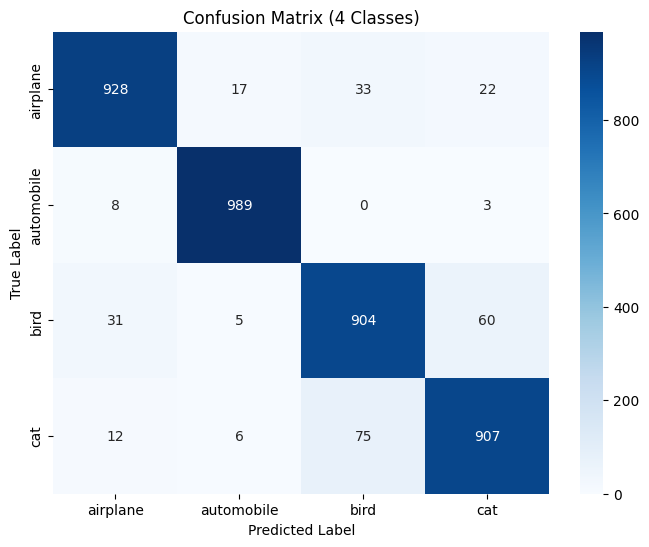

In [19]:
# Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test_4_classes, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_4_classes,
            yticklabels=class_names_4_classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (4 Classes)')
plt.show()

## Konversi Model

In [21]:
# Buat folder jika belum ada
os.makedirs("saved_models", exist_ok=True)

# Export model ke format SavedModel
saved_model_path = "saved_models/cifar10_saved_model"
best_model.export(saved_model_path)
print(f"Model SavedModel berhasil disimpan di: {saved_model_path}")

Saved artifact at 'saved_models/cifar10_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  136140552404432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136140552404240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136140551462288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136140551462672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136140551464592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136140551462864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136140551456144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136140551463056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136140551465360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136140551464784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1

In [22]:
# Konversi model Keras ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
tflite_model = converter.convert()

# Simpan model TFLite
tflite_model_path = "saved_models/cifar10_model.tflite"
with open(tflite_model_path, 'wb') as f:
    f.write(tflite_model)

print(f"Model TensorFlow Lite berhasil disimpan di: {tflite_model_path}")

Saved artifact at '/tmp/tmpurrx11tj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  136140552404432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136140552404240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136140551462288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136140551462672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136140551464592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136140551462864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136140551456144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136140551463056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136140551465360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136140551464784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136140551465168: 

In [27]:
# Folder tujuan untuk TFJS
tfjs_target_dir = "saved_models/cifar10_tfjs"

# Simpan model ke format TFJS
tfjs.converters.save_keras_model(best_model, tfjs_target_dir)
print(f"Model TensorFlow.js berhasil disimpan di: {tfjs_target_dir}")

failed to lookup keras version from the file,
    this is likely a weight only file
Model TensorFlow.js berhasil disimpan di: saved_models/cifar10_tfjs


## Inference (Optional)

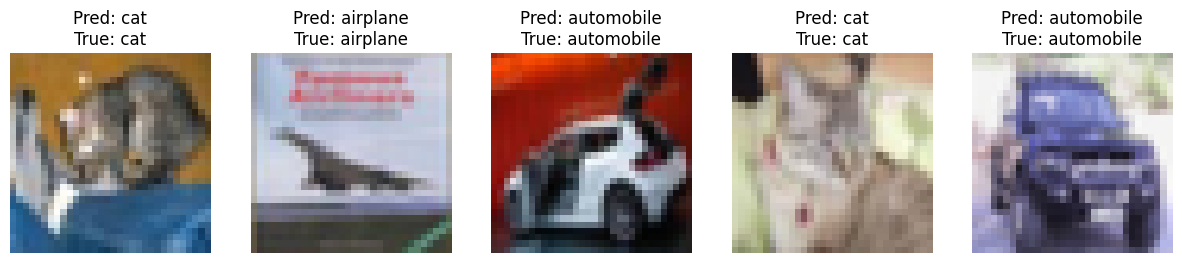

In [30]:
# --- Abaikan warning UserWarning TF Lite ---
warnings.filterwarnings("ignore", category=UserWarning)

# --- Load TFLite model ---
tflite_model_path = "saved_models/cifar10_model.tflite"
interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
interpreter.allocate_tensors()

# Ambil input dan output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# --- Fungsi prediksi TFLite ---
def tflite_predict(interpreter, x):
    """
    x: single image, shape (H, W, C), dtype float32
    """
    # TFLite expects batch dimension
    input_data = np.expand_dims(x, axis=0).astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    return np.argmax(output_data, axis=1)[0]

# --- Contoh inference ---
# Ambil beberapa gambar dari test set (pastikan ini 4 kelas yang difilter)
num_samples = 5
sample_images = x_test_4_classes[:num_samples]
sample_labels = y_test_4_classes[:num_samples]

plt.figure(figsize=(15,5))
for i, img in enumerate(sample_images):
    pred_class = tflite_predict(interpreter, img)
    true_class = sample_labels[i]

    plt.subplot(1, num_samples, i+1)
    plt.imshow(img)
    plt.title(f"Pred: {class_names_4_classes[pred_class]}\nTrue: {class_names_4_classes[true_class]}")
    plt.axis('off')
plt.show()

In [33]:
!pip freeze requirements.txt

absl-py==1.4.0
absolufy-imports==0.3.1
accelerate==1.10.1
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.12.15
aiosignal==1.4.0
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.16.5
altair==5.5.0
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.10.0
anywidget==0.9.18
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.1
arrow==1.3.0
arviz==0.22.0
astropy==7.1.0
astropy-iers-data==0.2025.9.15.0.37.0
astunparse==1.6.3
atpublic==5.1
attrs==25.3.0
audioread==3.0.1
Authlib==1.6.4
autograd==1.8.0
babel==2.17.0
backcall==0.2.0
beartype==0.21.0
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.21.0
bigquery-magics==0.10.3
bleach==6.2.0
blinker==1.9.0
blis==1.3.0
blobfile==3.1.0
blosc2==3.8.0
bokeh==3.7.3
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.1
Brotli==1.1.0
build==1.3.0
CacheControl==0.14.3
cachetools==5.5.2
catalogue==2.0.10
certifi==2025.8.3
cffi==2.0.0
chardet==5.2.0
charset-normalizer==3.4.3
chex==0.1.90
clara